
# Problemas de repaso – Examen corto Práctico 1
Parcial 1 repaso - Machine Learning


# 1) Se considera una variable aleatoria que tiene distribución Logística que depende de valores de μ y de s.

• Obtener tres muestras de tamaño n = 20, n = 200 y n = 20000 tomando μ = 25 y s = 4,  
  y realizar una representación de cada muestra en un histograma.  
  Usar np.random.logistic(25,4,n) para obtener las muestras.

• Determinar la media y la varianza de cada una de las muestras.

• Si la media exacta es μ y la varianza es (π²/3) s², comparar con los resultados previos.



## Explicación teórica

La distribución logística es una variable aleatoria continua.

Sus parámetros son:
- μ → media teórica
- s → parámetro de escala

Sabemos que:

Media teórica = μ  
Varianza teórica = (π²/3) s²  

En este ejercicio:
μ = 25  
s = 4  

Entonces:

Varianza teórica = (π²/3) * 4²


In [1]:
# Primero importamos las librerías necesarias
import numpy as np        # Para cálculos numéricos y generación de muestras
import matplotlib.pyplot as plt   # Para hacer gráficos

In [2]:
# Calculamos la varianza teórica

mu = 25
s = 4

var_teorica = (np.pi**2 / 3) * s**2
print("Media teórica:", mu)
print("Varianza teórica:", var_teorica)


Media teórica: 25
Varianza teórica: 52.637890139143245



Ahora generamos las tres muestras solicitadas.


In [3]:
muestra1 = np.random.logistic(25, 4, 20)
muestra2 = np.random.logistic(25, 4, 200)
muestra3 = np.random.logistic(25, 4, 20000)



Representamos cada muestra mediante un histograma.


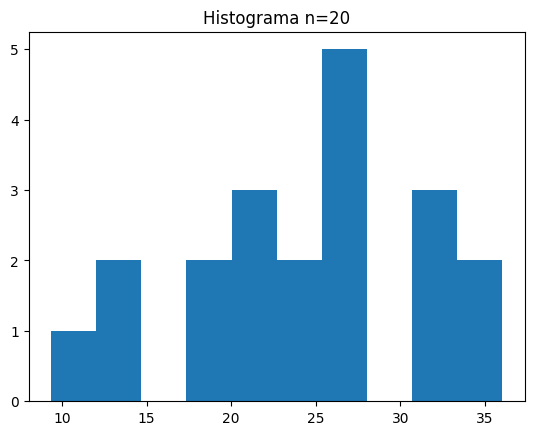

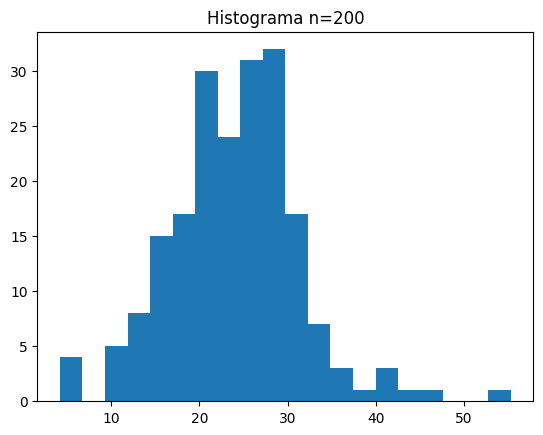

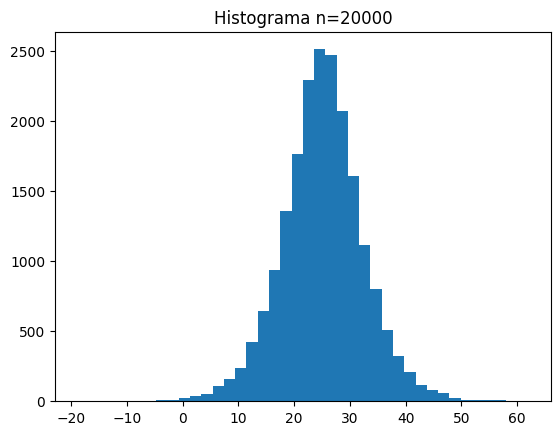

In [4]:
plt.hist(muestra1, bins=10)
plt.title("Histograma n=20")
plt.show()

plt.hist(muestra2, bins=20)
plt.title("Histograma n=200")
plt.show()

plt.hist(muestra3, bins=40)
plt.title("Histograma n=20000")
plt.show()



Calculamos ahora la media y varianza muestral.


In [5]:
print("n=20 -> Media:", np.mean(muestra1), " Var:", np.var(muestra1))
print("n=200 -> Media:", np.mean(muestra2), " Var:", np.var(muestra2))
print("n=20000 -> Media:", np.mean(muestra3), " Var:", np.var(muestra3))


n=20 -> Media: 24.27757378009596  Var: 52.387614664262685
n=200 -> Media: 23.984080975963522  Var: 53.85201446572917
n=20000 -> Media: 25.129370366127958  Var: 53.52433569267925



### Conclusión

A medida que aumenta n:

- La media muestral se aproxima a 25.
- La varianza muestral se aproxima al valor teórico.
- El histograma se estabiliza.

Esto confirma la Ley de los Grandes Números.



# 2) Se toma una muestra de tamaño n = 45 que tiene una distribución beta con valores de α = 0.5 y β = 3.
Reemplazar el primer valor de la muestra con el valor atípico 1 − 10⁻³.

• Calcular la media recortada al 15%, al 20% y la centrimedia.  
• Calcular la media winsorizada al 25%.  
• Calcular la trimedia.  
• Realizar un gráfico de cajas y bigote.  
• Comparar con la media muestral.



## Explicación

La distribución Beta genera valores entre 0 y 1.

Se introduce un valor atípico muy cercano a 1:
1 - 10⁻³ = 0.999

Esto altera la media clásica.

La estadística robusta intenta reducir ese efecto.


In [6]:
from scipy import stats   # Librería para funciones estadísticas

muestra = np.random.beta(0.5, 3, 45)

# Introducimos el valor atípico
muestra[0] = 1 - 10**(-3)

media_normal = np.mean(muestra)
media_15 = stats.trim_mean(muestra, 0.15)
media_20 = stats.trim_mean(muestra, 0.20)
centrimedia = stats.trim_mean(muestra, 0.25)

wins = stats.mstats.winsorize(muestra, limits=0.25)
media_wins = np.mean(wins)

Q1 = np.percentile(muestra, 25)
Q2 = np.percentile(muestra, 50)
Q3 = np.percentile(muestra, 75)
trimedia = (Q1 + 2*Q2 + Q3)/4

print("Media normal:", media_normal)
print("Media recortada 15%:", media_15)
print("Media recortada 20%:", media_20)
print("Centrimedia:", centrimedia)
print("Media winsorizada:", media_wins)
print("Trimedia:", trimedia)


Media normal: 0.19207040739486167
Media recortada 15%: 0.14711565770642104
Media recortada 20%: 0.13892279676898106
Centrimedia: 0.1356123646504828
Media winsorizada: 0.14604757403096513
Trimedia: 0.13501824853017347


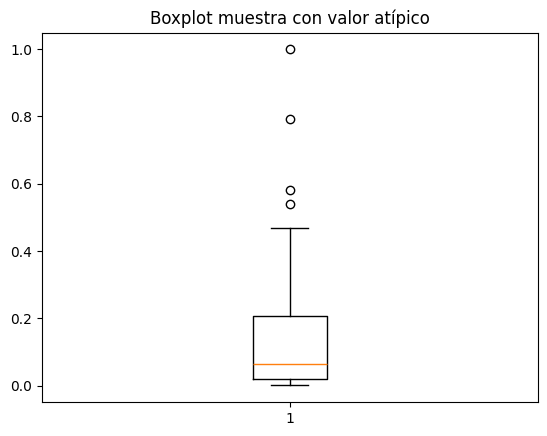

In [8]:

plt.boxplot(muestra)
plt.title("Boxplot muestra con valor atípico")
plt.show()



### Conclusión

La media normal es la más afectada por el valor atípico.
Las medidas robustas (recortadas, winsorizada, trimedia)
son más estables.



# 3) Simular las siguientes muestras:

• Una muestra x con distribución uniforme en intervalo [-2,2] de tamaño n = 400.  
• Una muestra ε con distribución normal con media 0 y desviación estándar 1, tamaño n = 400.

Construir:

y₁ = 2 + 4x + 4x²ε  
y₂ = 2 + 4x + ε  

• Obtener un modelo de regresión lineal para cada muestra.  
• Representar gráficamente los residuos.  
• Realizar la prueba de Breusch-Pagan.



## Explicación

Si la varianza del error depende de x → heterocedasticidad.

Si la varianza es constante → homocedasticidad.


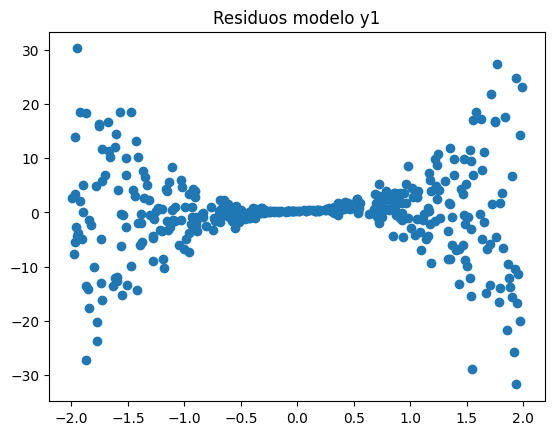

Breusch-Pagan y1: 0.12261457520976395


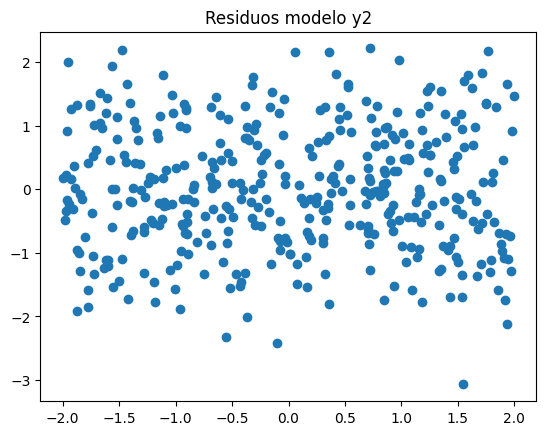

Breusch-Pagan y2: 0.3435494150792099


In [9]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

x = np.random.uniform(-2, 2, 400)
epsilon = np.random.normal(0, 1, 400)

y1 = 2 + 4*x + 4*(x**2)*epsilon
y2 = 2 + 4*x + epsilon

X = sm.add_constant(x)

modelo1 = sm.OLS(y1, X).fit()
res1 = modelo1.resid

plt.scatter(x, res1)
plt.title("Residuos modelo y1")
plt.show()

print("Breusch-Pagan y1:", het_breuschpagan(res1, X)[1])

modelo2 = sm.OLS(y2, X).fit()
res2 = modelo2.resid

plt.scatter(x, res2)
plt.title("Residuos modelo y2")
plt.show()

print("Breusch-Pagan y2:", het_breuschpagan(res2, X)[1])



### Conclusión

Si el p-valor < 0.05 → existe heterocedasticidad.

Se espera que:
- y₁ tenga heterocedasticidad.
- y₂ tenga homocedasticidad.
